Antes:
Counter({1: 1496, 2: 259, 3: 158})

Depois:
Counter({1: 518, 2: 259, 3: 158})
Decision Tree & [0.9091&0.8877&0.8717&0.9251&0.877&] & 0.8941 & 0.9061032863849765


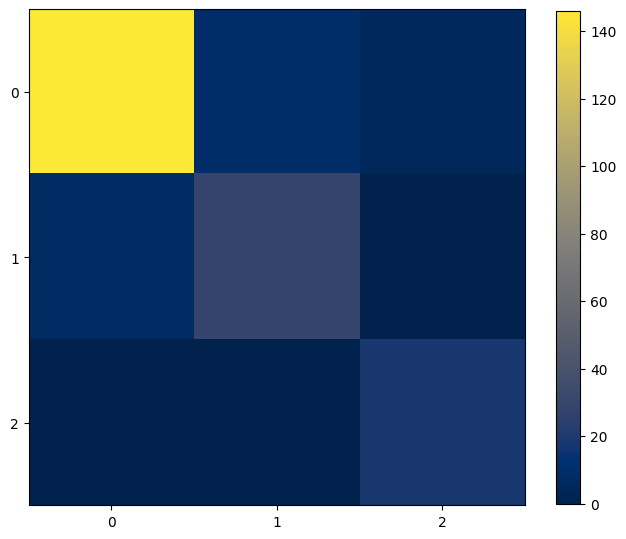

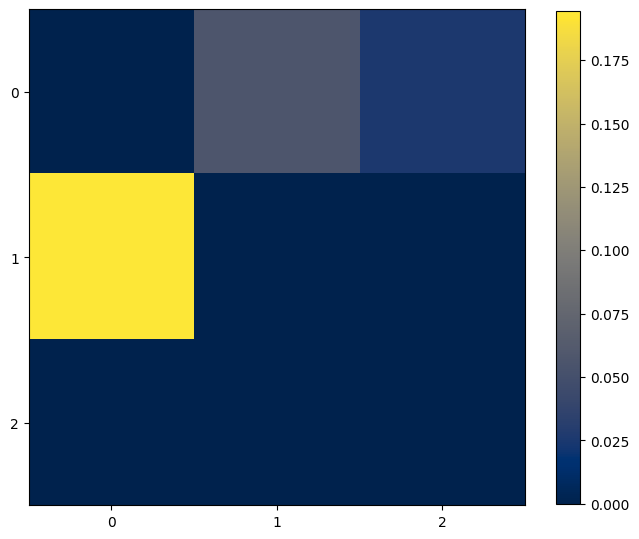

Random Forest & [0.9305&0.9091&0.9412&0.9251&0.9091] & 0.923 & 0.9154929577464789


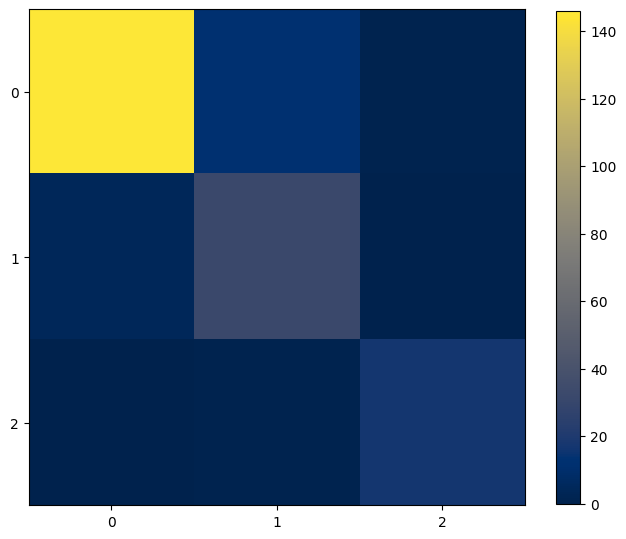

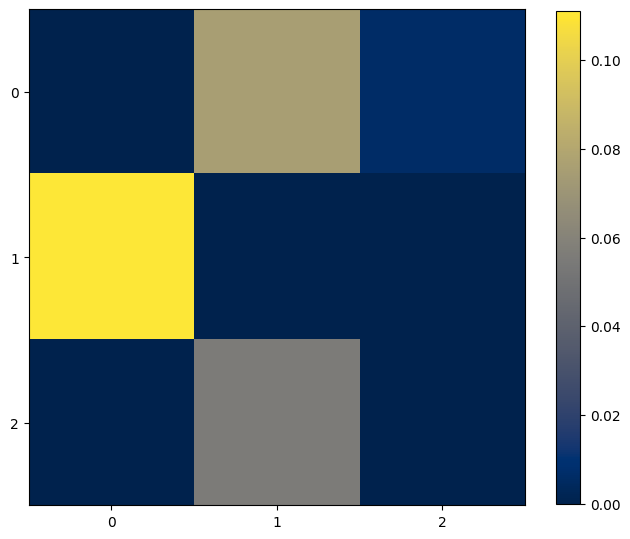

SVM & [0.8556&0.7701&0.8235&0.8556&0.8396] & 0.8289 & 0.8215962441314554


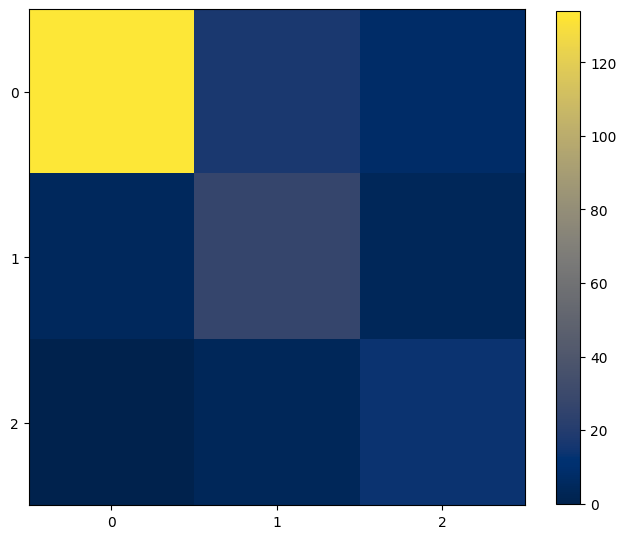

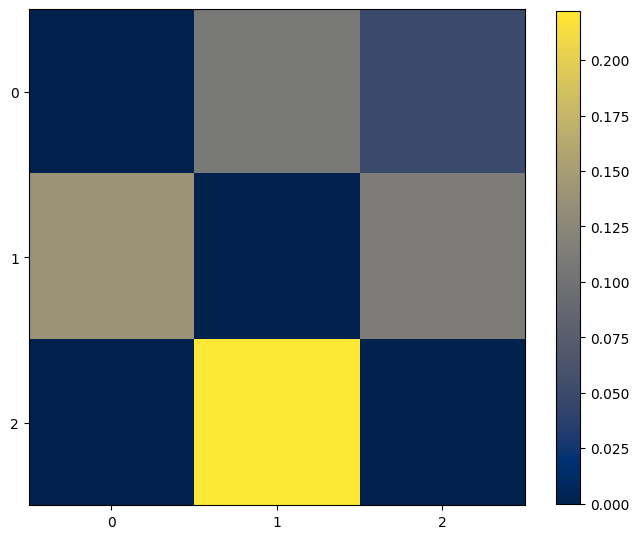

Naive Bayes & [0.8556&0.7487&0.7701&0.7701&0.7968] & 0.7882 & 0.7417840375586855


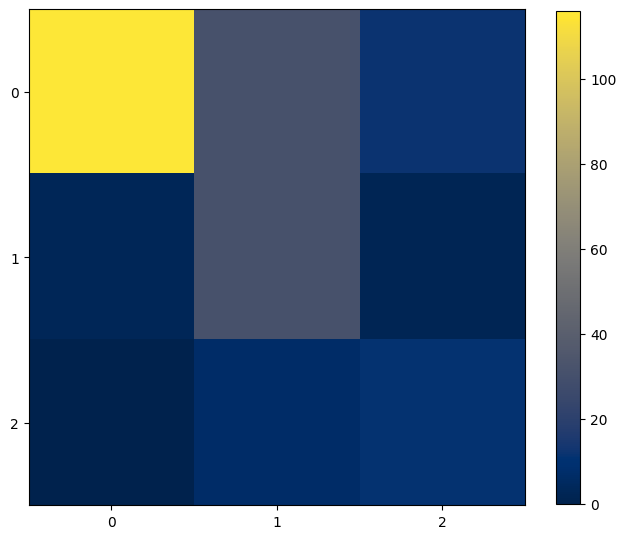

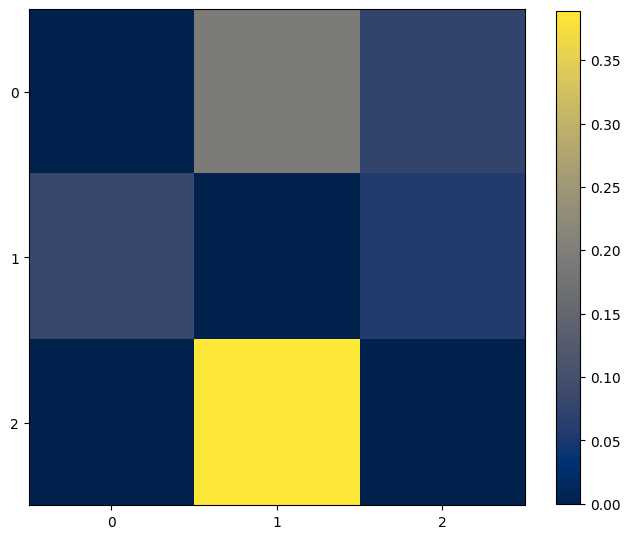

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.preprocessing import label_binarize
from sklearn.metrics import roc_curve, auc

from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.naive_bayes import GaussianNB

from sklearn.decomposition import PCA

from imblearn.under_sampling import RandomUnderSampler
from sklearn.metrics import classification_report, accuracy_score, confusion_matrix
from sklearn.model_selection import cross_val_score
from sklearn.model_selection import GridSearchCV
from collections import Counter

# ----------------------------
# Classificadores
# ----------------------------

Ytrain  = pd.read_pickle('../data/ytrain.pkl')
Ytest   = pd.read_pickle('../data/ytest.pkl')

Xtrain  = pd.read_pickle('../data/xtrain.pkl')
Xtest   = pd.read_pickle('../data/xtest.pkl')



print("Antes:")
print(Counter(Ytrain))

rus = RandomUnderSampler(
    sampling_strategy={
        1:518,
        2:259,
        3:158
    },
    random_state=42
)

Xtrain_under, Ytrain_under = rus.fit_resample(Xtrain, Ytrain)

print("\nDepois:")
print(Counter(Ytrain_under))


dt_classificador = DecisionTreeClassifier(criterion='entropy', max_depth=30, min_samples_leaf=4, min_samples_split=19, random_state=42)
rf = RandomForestClassifier(criterion='entropy', max_depth=30, min_samples_split=3,
                       n_estimators=np.int64(450), random_state=42)
svm = SVC(kernel='poly', degree=4)
nb = GaussianNB()

classificadores = [dt_classificador, rf, svm, nb]
nomeClassificadores = ['Decision Tree', 'Random Forest', 'SVM', 'Naive Bayes']


for i, classificador in enumerate(classificadores):
    classificador.fit(Xtrain_under, Ytrain_under)

    #print(nomeClassificadores[i])
    

    escores_cv = cross_val_score(classificador, Xtrain_under, Ytrain_under, cv=5)
    ypred = classificador.predict(Xtest)
    print(f'{nomeClassificadores[i]} & {str(escores_cv.round(4)).replace(' ', '&')} & {np.mean(escores_cv).round(4)} & {accuracy_score(ypred, Ytest)}')
    

    conf_mat = confusion_matrix(Ytest, ypred, labels=[1, 2, 3])
    plt.figure(figsize=(8, 8))
    plt.imshow(conf_mat, cmap='cividis')
    plt.xticks(ticks=[0,1,2])
    plt.yticks(ticks=[0,1,2])
    plt.colorbar(shrink = 0.8)
    plt.savefig(f'../results2/ConMatrix{nomeClassificadores[i]}Under.png')
    plt.show()


    conf_matrix_relative = conf_mat.copy()
    np.fill_diagonal(conf_matrix_relative, val = 0)
    conf_matrix_relative = conf_matrix_relative/ conf_mat.sum(axis = 1, keepdims=True)

    plt.figure(figsize=(8, 8))
    plt.xticks(ticks=[0,1,2])
    plt.yticks(ticks=[0,1,2])
    plt.imshow(conf_matrix_relative, cmap='cividis')
    plt.colorbar(shrink = 0.8)
    plt.savefig(f'../results2/relativeConMatrix{nomeClassificadores[i]}Under.png')
    plt.show()
    #print(classification_report(Ytest, ypred))

    

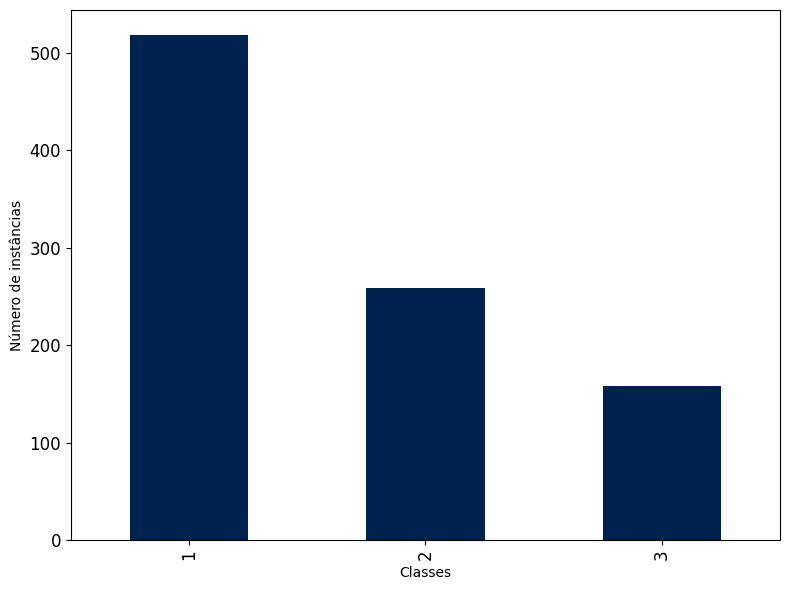

In [6]:
plt.figure(figsize=(8, 6))
plt.grid(True, alpha = 0.5)
Ytrain_under.value_counts().plot(kind='bar', cmap = 'cividis')
plt.ylabel("Número de instâncias")
plt.xlabel("Classes")
plt.xticks(fontsize = 12)
plt.yticks(fontsize = 12)
plt.tight_layout()
plt.savefig('frequencia_classes_Ytrain_under.png')
plt.show()